# Taller de código 1: algoritmos de búsqueda

Implementarás **BFS, UCS y A\*** sobre el mismo grafo. El objetivo no es solo encontrar una ruta, sino comparar:

- ruta encontrada;
- costo total;
- número y orden de nodos expandidos.

Tiempo estimado: **60–75 minutos**.

## Problema

Un agente debe viajar desde `S` hasta `G`. Las aristas tienen costos y cada nodo posee una heurística estimada hacia la meta.

| Nodo | $h(n)$ |
|---|---:|
| S | 6 |
| A | 4 |
| B | 3 |
| C | 5 |
| D | 2 |
| G | 0 |

In [21]:
from collections import deque
import heapq
import itertools
import pandas as pd
import matplotlib.pyplot as plt

graph = {
    "S": [("A", 2), ("B", 5)],
    "A": [("C", 2), ("D", 4)],
    "B": [("D", 1)],
    "C": [("G", 5)],
    "D": [("G", 2)],
    "G": [],
}

heuristic = {"S": 6, "A": 20, "B": 3, "C": 5, "D": 2, "G": 0}

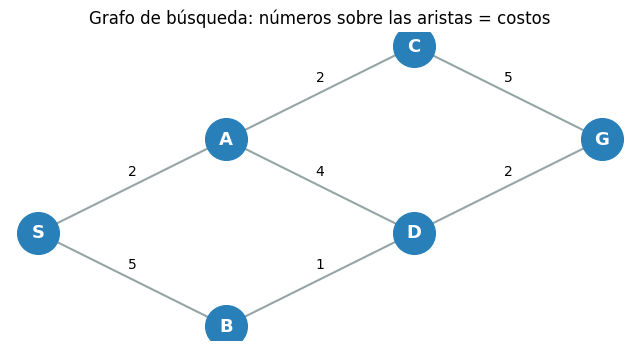

In [22]:
positions = {"S": (0, 1), "A": (1, 2), "B": (1, 0), "C": (2, 3), "D": (2, 1), "G": (3, 2)}

plt.figure(figsize=(8, 4))
for source, neighbors in graph.items():
    x1, y1 = positions[source]
    for target, cost in neighbors:
        x2, y2 = positions[target]
        plt.plot([x1, x2], [y1, y2], color="#95a5a6", zorder=1)
        plt.text((x1+x2)/2, (y1+y2)/2 + 0.12, str(cost), ha="center")
for node, (x, y) in positions.items():
    plt.scatter(x, y, s=900, color="#2980b9", zorder=2)
    plt.text(x, y, node, color="white", ha="center", va="center", fontsize=13, weight="bold")
plt.axis("off")
plt.title("Grafo de búsqueda: números sobre las aristas = costos")
plt.show()

## Actividad 1 — Reconstruir una ruta

In [23]:
def reconstruct_path(parent, goal):
    """Reconstruye la ruta desde el inicio hasta goal usando parent."""
    path = []
    node = goal
    while node is not None:          # llegamos al inicio cuando el padre es None
        path.append(node)
        node = parent[node]
    path.reverse()                    # armamos la lista de atrás (goal) hacia adelante (start)
    return path

In [24]:
# Prueba
example_parent = {"S": None, "A": "S", "D": "A", "G": "D"}
assert reconstruct_path(example_parent, "G") == ["S", "A", "D", "G"]
print("Prueba 1 superada.")

Prueba 1 superada.


## Actividad 2 — BFS

Completa BFS usando una cola FIFO. Ignora los costos al decidir qué nodo expandir, pero calcula el costo de la ruta encontrada al final.

In [17]:
def path_cost(graph, path):
    total = 0
    for source, target in zip(path, path[1:]):
        total += dict(graph[source])[target]
    return total


def bfs(graph, start, goal):
    """Devuelve path, cost y expanded_order."""
    frontier = deque([start])        # cola FIFO (First In First Out)
    visited = {start}                # marcamos como visitado apenas se encola 
    parent = {start: None}
    expanded_order = []

    while frontier:
        node = frontier.popleft()    # BFS al nodo mas antiguo
        expanded_order.append(node)

        if node == goal:             # si llega a la meta para
            break

        for neighbor, _cost in graph[node]:   # BFS para realizar el recorrido
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = node
                frontier.append(neighbor)

    path = reconstruct_path(parent, goal)
    cost = path_cost(graph, path)     # el costo se calcula al final, no durante la búsqueda
    return path, cost, expanded_order

In [18]:
path_bfs, cost_bfs, expanded_bfs = bfs(graph, "S", "G")
assert path_bfs[0] == "S" and path_bfs[-1] == "G"
assert len(path_bfs) == 4
print(path_bfs, cost_bfs, expanded_bfs)

['S', 'A', 'C', 'G'] 9 ['S', 'A', 'B', 'C', 'D', 'G']


## Actividad 3 — Uniform Cost Search

Usa una cola de prioridad ordenada por $g(n)$. Si encuentras una ruta más barata hacia un nodo, actualiza su mejor costo y su padre.

In [19]:
def uniform_cost_search(graph, start, goal):
    """Devuelve path, cost y expanded_order."""
    counter = itertools.count()       # desempata cuando dos nodos tienen el mismo g(n)
    frontier = [(0, next(counter), start)]   # cola de prioridad: (g(n), desempate, nodo)
    best_cost = {start: 0}            # mejor costo conocido para llegar a cada nodo
    parent = {start: None}
    visited = set()
    expanded_order = []

    while frontier:
        cost, _, node = heapq.heappop(frontier)   # siempre sacamos el de menor g(n)

        if node in visited:       # si ya visito este nodo, se ignora
            continue
        visited.add(node)
        expanded_order.append(node)

        if node == goal:              # Acaba cuando llega a la meta
            break

        for neighbor, step_cost in graph[node]:
            new_cost = cost + step_cost
            if neighbor not in best_cost or new_cost < best_cost[neighbor]:
                best_cost[neighbor] = new_cost   # encontramos un camino más barato: actualizamos
                parent[neighbor] = node
                heapq.heappush(frontier, (new_cost, next(counter), neighbor))

    path = reconstruct_path(parent, goal)
    return path, best_cost[goal], expanded_order

In [20]:
path_ucs, cost_ucs, expanded_ucs = uniform_cost_search(graph, "S", "G")
assert cost_ucs == 8
assert path_ucs[0] == "S" and path_ucs[-1] == "G"
print(path_ucs, cost_ucs, expanded_ucs)

['S', 'A', 'D', 'G'] 8 ['S', 'A', 'C', 'B', 'D', 'G']


## Actividad 4 — A*

Implementa A* usando $f(n)=g(n)+h(n)$. La heurística se usa para ordenar la frontera, pero el costo acumulado real sigue siendo $g(n)$.

In [25]:
def a_star(graph, heuristic, start, goal):
    """Devuelve path, cost y expanded_order."""
    counter = itertools.count()
    # la prioridad en la cola es f(n) = g(n) + h(n)
    frontier = [(heuristic[start], 0, next(counter), start)]
    best_cost = {start: 0}            # este sí es el costo real acumulado, g(n)
    parent = {start: None}
    visited = set()
    expanded_order = []

    while frontier:
        _f, g, _, node = heapq.heappop(frontier)   # extraemos por menor f(n)

        if node in visited:
            continue
        visited.add(node)
        expanded_order.append(node)

        if node == goal:
            break

        for neighbor, step_cost in graph[node]:
            new_g = g + step_cost
            if neighbor not in best_cost or new_g < best_cost[neighbor]:
                best_cost[neighbor] = new_g
                parent[neighbor] = node
                new_f = new_g + heuristic[neighbor]   # h(n) solo ordena, no se acumula
                heapq.heappush(frontier, (new_f, new_g, next(counter), neighbor))

    path = reconstruct_path(parent, goal)
    return path, best_cost[goal], expanded_order

In [26]:
path_astar, cost_astar, expanded_astar = a_star(graph, heuristic, "S", "G")
assert cost_astar == 8
assert path_astar[0] == "S" and path_astar[-1] == "G"
print(path_astar, cost_astar, expanded_astar)

['S', 'B', 'D', 'G'] 8 ['S', 'B', 'D', 'G']


## Actividad 5 — Comparación

In [27]:
results = pd.DataFrame([
    {"algorithm": "BFS", "path": path_bfs, "cost": cost_bfs, "expanded": len(expanded_bfs)},
    {"algorithm": "UCS", "path": path_ucs, "cost": cost_ucs, "expanded": len(expanded_ucs)},
    {"algorithm": "A*", "path": path_astar, "cost": cost_astar, "expanded": len(expanded_astar)},
])
results

,algorithm,path,cost,expanded
0,BFS,"[S, A, C, G]",9,6
1,UCS,"[S, A, D, G]",8,6
2,A*,"[S, B, D, G]",8,4


## Preguntas de análisis

1. ¿Por qué BFS puede devolver una ruta con mayor costo aunque tenga el mismo número de aristas?
2. ¿Qué diferencia observas entre el orden de expansión de UCS y A*?
3. Cambia `heuristic["A"]` a `20`. ¿La heurística sigue siendo admisible? ¿Qué ocurre con el resultado?
4. ¿En qué parte del código se implementa realmente la estrategia de búsqueda: al generar sucesores o al extraer de la frontera?

## Checklist

- [ ] Reconstruí rutas correctamente.
- [ ] Implementé BFS con FIFO.
- [ ] Implementé UCS con prioridad $g(n)$.
- [ ] Implementé A* con prioridad $g(n)+h(n)$.
- [ ] Comparé costo y nodos expandidos.